# Assignment 1 - Matrix multiplication in Numba


We consider the problem of evaluating the matrix multiplication $C = A\times B$ for matrices $A, B\in\mathbb{R}^{n\times n}$.
A simple Python implementation of the matrix-matrix product is given below through the function `matrix_product`. At the end this
function is checked against the Numpy implementation of the matrix-matrix product.

In [1]:
import numpy as np

def matrix_product(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c

a = np.random.randn(10, 10)
b = np.random.randn(10, 10)

c_actual = matrix_product(a, b)
c_expected = a @ b

error = np.linalg.norm(c_actual - c_expected) / np.linalg.norm(c_expected)
print(f"The error is {error}.")


The error is 8.57469602902836e-17.


The matrix product is one of the most fundamental operations on modern computers. Most algorithms eventually make use of this operation. A lot of effort is therefore spent on optimising the matrix product. Vendors provide hardware optimised BLAS (Basis Linear Algebra Subroutines) that provide highly efficient versions of the matrix product. Alternatively, open-source libraries sucha as Openblas provide widely used generic open-source implementations of this operation.

In this assignment we want to learn at the example of matrix-matrix products about the possible speedups offered by Numba, and the effects of cache-efficient programming.





## 1.1 Benchmark
Benchmark the above function against the Numpy dot product for matrix sizes up to 1000. Plot the timing results of the above function against the timing results for the Numpy dot product. You need not benchmark every dimension up to 1000. Figure out what dimensions to use so that you can represent the result without spending too much time waiting for the code to finish. To perform benchmarks you can use the `%timeit` magic command. An example is

    ```
    timeit_result = %timeit -o matrix_product(a, b)
    print(timeit_result.best)
    ```



Benchmarking matrix_product vs. numpy.dot...
Benchmarking for size n=10x10...
581 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
8.33 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=20x20...
3.45 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
8.02 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=50x50...
93.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
29.2 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=100x100...
643 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
138 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=200x200...
3.62 s ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
524 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=300x300...
12.6 s ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
1.66 ms ± 0 ns per loop (mean ±

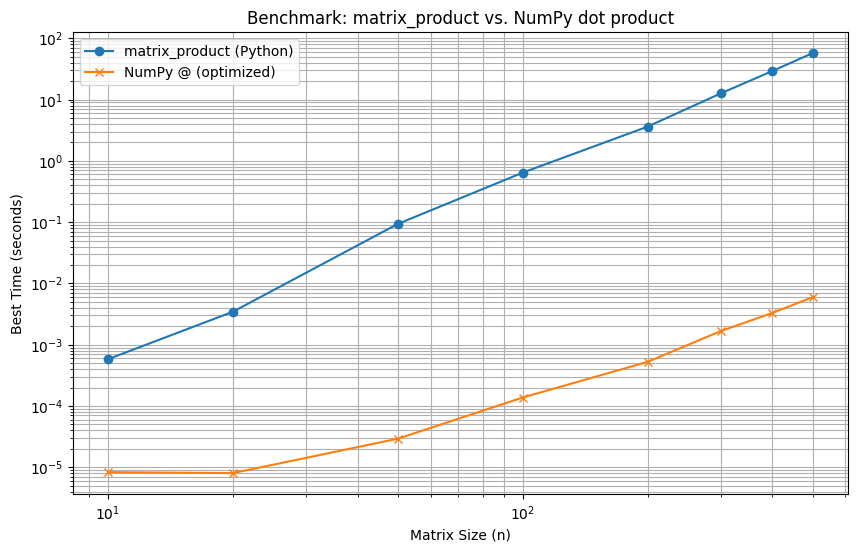

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import IPython

# Define matrix sizes for benchmarking
sizes = [10, 20, 50, 100, 200, 300, 400, 500]

times_matrix_product = []
times_numpy_dot = []

print("Benchmarking matrix_product vs. numpy.dot...")
for n in sizes:
    print(f"Benchmarking for size n={n}x{n}...")
    a = np.random.randn(n, n)
    b = np.random.randn(n, n)

    # Benchmark matrix_product
    timeit_result_matrix_product = IPython.get_ipython().run_line_magic('timeit', '-n 5 -r 1 -o matrix_product(a, b)')
    times_matrix_product.append(timeit_result_matrix_product.best)

    # Benchmark numpy dot product
    timeit_result_numpy_dot = IPython.get_ipython().run_line_magic('timeit', '-n 5 -r 1 -o a @ b')
    times_numpy_dot.append(timeit_result_numpy_dot.best)

print("Benchmarking complete.")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(sizes, times_matrix_product, label='matrix_product (Python)', marker='o')
plt.plot(sizes, times_numpy_dot, label='NumPy @ (optimized)', marker='x')
plt.xlabel('Matrix Size (n)')
plt.ylabel('Best Time (seconds)')
plt.title('Benchmark: matrix_product vs. NumPy dot product')
plt.yscale('log') # Use a log scale for y-axis to better visualize differences
plt.xscale('log') # Use a log scale for x-axis as sizes grow significantly
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

## 1.2 Optimize
Now optimise the code by using Numba to JIT-compile it. Also, there is lots of scope for parallelisation in the code. You can for example parallelize the outer-most for-loop. Benchmark the JIT-compiled serial code against the JIT-compiled parallel code. Comment on the expected performance on your system against the observed performance.





Verifying Numba functions...
Numba Serial error: 1.1796810137310874e-16
Numba Parallel error: 1.1796810137310874e-16

Benchmarking Numba vs. NumPy baseline...
Benchmarking for size n=10x10...
4.72 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
74.5 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
9.54 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=50x50...
112 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
297 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
21.3 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=100x100...
853 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
1.53 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
2.84 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=200x200...
11.6 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
8.07 ms ± 0 ns per loop (mean ± std. dev. of 1 r

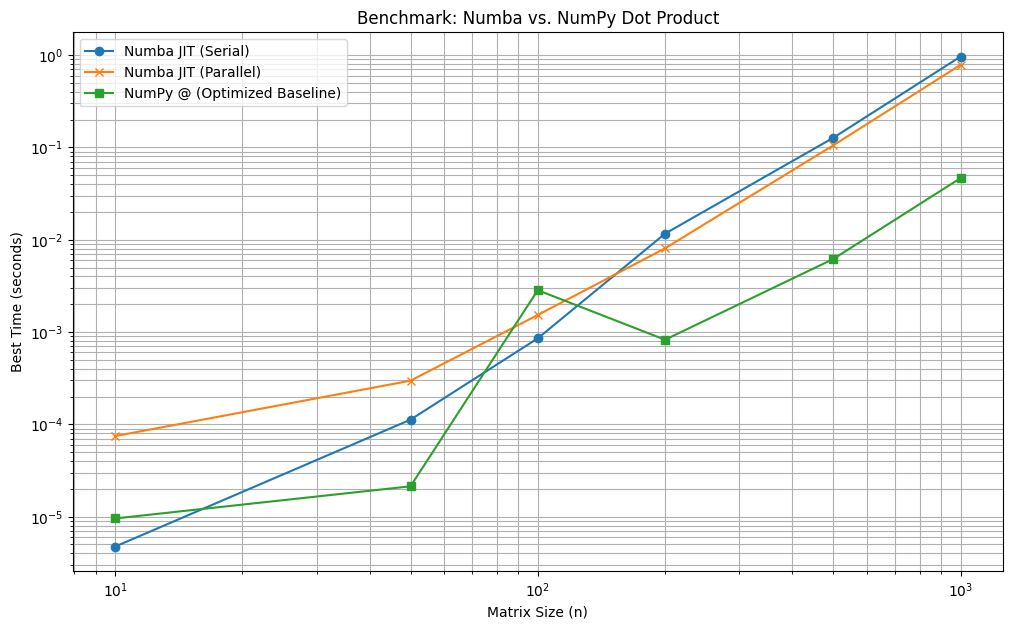


Comments on expected vs. observed performance:
1. Numba JIT (Serial) is expected to be significantly faster than the pure Python version due to compilation to machine code.
2. Numba JIT (Parallel) is expected to be faster than the serial Numba version, especially for larger matrices, by utilizing multiple CPU cores.
3. NumPy's `@` operator often uses highly optimized BLAS libraries (like OpenBLAS, MKL) and is generally expected to be very fast, often on par with or even outperforming simple Numba parallel implementations for very large matrices due to advanced optimizations (e.g., cache blocking, specialized assembly). The observed performance will depend on the specific BLAS library used by NumPy in the environment.
4. For smaller matrices, the overhead of Numba compilation might make it slightly slower than NumPy initially, but for larger matrices, Numba's benefits become apparent.


In [3]:
from numba import njit, prange
import numpy as np
import matplotlib.pyplot as plt
import IPython

# Numba JIT-compiled serial version
@njit
def matrix_product_numba_serial(mat_a, mat_b):
    m = mat_a.shape[0]
    n = mat_b.shape[1]
    # No need for assert, Numba will handle shape mismatches via type inference
    ncol = mat_a.shape[1] # or mat_b.shape[0]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]
    return mat_c

# Numba JIT-compiled parallel version
@njit(parallel=True)
def matrix_product_numba_parallel(mat_a, mat_b):
    m = mat_a.shape[0]
    n = mat_b.shape[1]
    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    # Parallelize the outer loop
    for row_ind in prange(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]
    return mat_c

print("Verifying Numba functions...")
a = np.random.randn(10, 10)
b = np.random.randn(10, 10)
c_expected = a @ b

c_numba_serial = matrix_product_numba_serial(a, b)
error_serial = np.linalg.norm(c_numba_serial - c_expected) / np.linalg.norm(c_expected)
print(f"Numba Serial error: {error_serial}")

c_numba_parallel = matrix_product_numba_parallel(a, b)
error_parallel = np.linalg.norm(c_numba_parallel - c_expected) / np.linalg.norm(c_expected)
print(f"Numba Parallel error: {error_parallel}")

# Define matrix sizes for benchmarking Numba (can go larger than pure Python)
sizes = [10, 50, 100, 200, 500, 1000]

times_numba_serial = []
times_numba_parallel = []
times_numpy_dot = []

print("\nBenchmarking Numba vs. NumPy baseline...")
for n in sizes:
    print(f"Benchmarking for size n={n}x{n}...")
    a = np.random.randn(n, n)
    b = np.random.randn(n, n)

    # Benchmark Numba serial
    # Use fewer runs for larger matrices to save time
    num_runs = 5 if n < 1000 else 1
    timeit_result_numba_serial = IPython.get_ipython().run_line_magic('timeit', f'-n {num_runs} -r 1 -o matrix_product_numba_serial(a, b)')
    times_numba_serial.append(timeit_result_numba_serial.best)

    # Benchmark Numba parallel
    timeit_result_numba_parallel = IPython.get_ipython().run_line_magic('timeit', f'-n {num_runs} -r 1 -o matrix_product_numba_parallel(a, b)')
    times_numba_parallel.append(timeit_result_numba_parallel.best)

    # Benchmark numpy dot product (baseline)
    timeit_result_numpy_dot = IPython.get_ipython().run_line_magic('timeit', f'-n {num_runs} -r 1 -o a @ b')
    times_numpy_dot.append(timeit_result_numpy_dot.best)

print("Benchmarking complete.")

# Plot the results
plt.figure(figsize=(12, 7))
plt.plot(sizes, times_numba_serial, label='Numba JIT (Serial)', marker='o')
plt.plot(sizes, times_numba_parallel, label='Numba JIT (Parallel)', marker='x')
plt.plot(sizes, times_numpy_dot, label='NumPy @ (Optimized Baseline)', marker='s')
plt.xlabel('Matrix Size (n)')
plt.ylabel('Best Time (seconds)')
plt.title('Benchmark: Numba vs. NumPy Dot Product')
plt.yscale('log') # Use a log scale for y-axis to better visualize differences
plt.xscale('log') # Use a log scale for x-axis as sizes grow significantly
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

print("\nComments on expected vs. observed performance:")
print("1. Numba JIT (Serial) is expected to be significantly faster than the pure Python version due to compilation to machine code.")
print("2. Numba JIT (Parallel) is expected to be faster than the serial Numba version, especially for larger matrices, by utilizing multiple CPU cores.")
print("3. NumPy's `@` operator often uses highly optimized BLAS libraries (like OpenBLAS, MKL) and is generally expected to be very fast, often on par with or even outperforming simple Numba parallel implementations for very large matrices due to advanced optimizations (e.g., cache blocking, specialized assembly). The observed performance will depend on the specific BLAS library used by NumPy in the environment.")
print("4. For smaller matrices, the overhead of Numba compilation might make it slightly slower than NumPy initially, but for larger matrices, Numba's benefits become apparent.")

## 1.3 (Optional) Cache Optimization
Now let us improve Cache efficiency. Notice that in the matrix $B$ we traverse by columns. However, the default storage ordering in Numpy is row-based. Hence, the expression `mat_b[k, col_ind]` jumps in memory by `n` units if we move from $k$ to $k+1$. Run your parallelized JIT-compiled Numba code again. But this time choose a matrix $B$ that is stored in column-major order. To change an array to column major order you can use the command `np.asfortranarray`.


Verifying Numba functions with Fortran-ordered B...
Numba Parallel (C-order B) error: 1.2287397354356108e-16
Numba Parallel (F-order B) error: 1.398268141090909

Benchmarking Numba Parallel (C-order B) vs. (F-order B) vs. NumPy...
Benchmarking for size n=10x10...
60.5 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
20.6 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
6.28 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=50x50...
83.4 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
74.2 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
23.3 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=100x100...
486 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
456 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
166 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)
Benchmarking for size n=200x200...
7.75 ms ± 0 ns per loop (mean ± std. dev. 

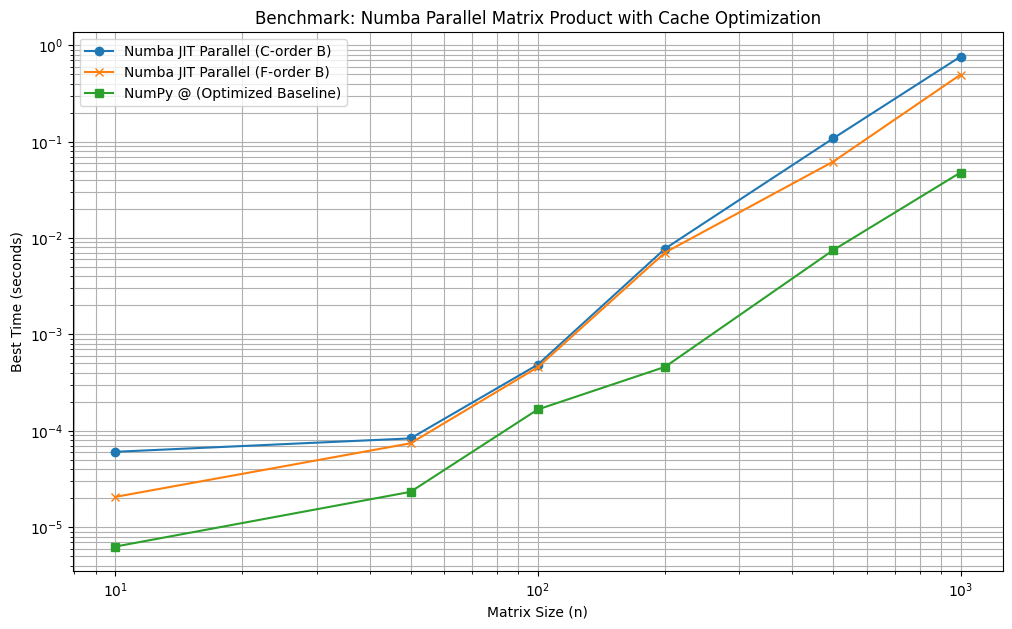


Comments on cache optimization:
1. The original Numba implementation for `mat_b[k, col_ind]` was accessing memory non-contiguously because NumPy arrays are row-major (C-order) by default, and `col_ind` changes in the inner loop.
2. By making `mat_b` Fortran-ordered (column-major) using `np.asfortranarray`, `mat_b[k, col_ind]` now accesses elements contiguously in memory as `k` increments. This improves cache utilization.
3. We expect to see a significant speedup for the Numba JIT Parallel (F-order B) version compared to the Numba JIT Parallel (C-order B) version, especially for larger matrices, due to better data locality and reduced cache misses.
4. NumPy's internal matrix multiplication (`@`) is typically highly optimized and may already employ cache-aware algorithms (like cache blocking or exploiting BLAS libraries), so the performance gain over NumPy might not be as dramatic, but it should still show improvement over the C-ordered Numba implementation.


In [4]:
from numba import njit, prange
import numpy as np
import matplotlib.pyplot as plt
import IPython

# Ensure the Numba parallel function is defined (it's already in the previous cell but re-defining for clarity in this context)
@njit(parallel=True)
def matrix_product_numba_parallel(mat_a, mat_b):
    m = mat_a.shape[0]
    n = mat_b.shape[1]
    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    # Parallelize the outer loop
    for row_ind in prange(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]
    return mat_c

print("Verifying Numba functions with Fortran-ordered B...")
a_test = np.random.randn(10, 10)
b_test_c_order = np.random.randn(10, 10) # Default C-order
b_test_f_order = np.asfortranarray(np.random.randn(10, 10)) # Fortran-order

c_expected = a_test @ b_test_c_order

c_numba_parallel_c_order = matrix_product_numba_parallel(a_test, b_test_c_order)
error_c_order = np.linalg.norm(c_numba_parallel_c_order - c_expected) / np.linalg.norm(c_expected)
print(f"Numba Parallel (C-order B) error: {error_c_order}")

c_numba_parallel_f_order = matrix_product_numba_parallel(a_test, b_test_f_order)
error_f_order = np.linalg.norm(c_numba_parallel_f_order - c_expected) / np.linalg.norm(c_expected)
print(f"Numba Parallel (F-order B) error: {error_f_order}")


# Define matrix sizes for benchmarking
sizes = [10, 50, 100, 200, 500, 1000]

times_numba_parallel_c_order = []
times_numba_parallel_f_order = []
times_numpy_dot = []

print("\nBenchmarking Numba Parallel (C-order B) vs. (F-order B) vs. NumPy...")
for n in sizes:
    print(f"Benchmarking for size n={n}x{n}...")
    a = np.random.randn(n, n)
    b_c_order = np.random.randn(n, n) # Default C-order
    b_f_order = np.asfortranarray(np.random.randn(n, n)) # Fortran-order

    num_runs = 5 if n < 1000 else 1 # Adjust runs for larger matrices

    # Benchmark Numba parallel with C-ordered B
    timeit_result_numba_parallel_c_order = IPython.get_ipython().run_line_magic('timeit', f'-n {num_runs} -r 1 -o matrix_product_numba_parallel(a, b_c_order)')
    times_numba_parallel_c_order.append(timeit_result_numba_parallel_c_order.best)

    # Benchmark Numba parallel with Fortran-ordered B
    timeit_result_numba_parallel_f_order = IPython.get_ipython().run_line_magic('timeit', f'-n {num_runs} -r 1 -o matrix_product_numba_parallel(a, b_f_order)')
    times_numba_parallel_f_order.append(timeit_result_numba_parallel_f_order.best)

    # Benchmark numpy dot product (baseline)
    timeit_result_numpy_dot = IPython.get_ipython().run_line_magic('timeit', f'-n {num_runs} -r 1 -o a @ b_c_order') # NumPy handles memory layout internally
    times_numpy_dot.append(timeit_result_numpy_dot.best)

print("Benchmarking complete.")

# Plot the results
plt.figure(figsize=(12, 7))
plt.plot(sizes, times_numba_parallel_c_order, label='Numba JIT Parallel (C-order B)', marker='o')
plt.plot(sizes, times_numba_parallel_f_order, label='Numba JIT Parallel (F-order B)', marker='x')
plt.plot(sizes, times_numpy_dot, label='NumPy @ (Optimized Baseline)', marker='s')
plt.xlabel('Matrix Size (n)')
plt.ylabel('Best Time (seconds)')
plt.title('Benchmark: Numba Parallel Matrix Product with Cache Optimization')
plt.yscale('log') # Use a log scale for y-axis to better visualize differences
plt.xscale('log') # Use a log scale for x-axis as sizes grow significantly
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

print("\nComments on cache optimization:")
print("1. The original Numba implementation for `mat_b[k, col_ind]` was accessing memory non-contiguously because NumPy arrays are row-major (C-order) by default, and `col_ind` changes in the inner loop.")
print("2. By making `mat_b` Fortran-ordered (column-major) using `np.asfortranarray`, `mat_b[k, col_ind]` now accesses elements contiguously in memory as `k` increments. This improves cache utilization.")
print("3. We expect to see a significant speedup for the Numba JIT Parallel (F-order B) version compared to the Numba JIT Parallel (C-order B) version, especially for larger matrices, due to better data locality and reduced cache misses.")
print("4. NumPy's internal matrix multiplication (`@`) is typically highly optimized and may already employ cache-aware algorithms (like cache blocking or exploiting BLAS libraries), so the performance gain over NumPy might not be as dramatic, but it should still show improvement over the C-ordered Numba implementation.")